# AI Resume Screening System
**Tools:** Python, LangChain, OpenRouter API, LangSmith

OpenRouter gives access to many free models (Llama, Mistral, Gemma etc.) through one API key.
It uses the same interface as OpenAI so langchain-openai works without any changes.

Pipeline: Resume + Job Description -> Skill Extraction -> Matching -> Scoring -> Explanation

**Get your keys:**
- OpenRouter key -> https://openrouter.ai -> Sign up -> Keys -> Create Key (free, no card needed)
- LangSmith key  -> https://smith.langchain.com -> Settings -> API Keys -> Create API Key (free)

In [ ]:
# openrouter uses the openai-compatible API so we just need langchain-openai
# no special package needed
!pip install -q langchain langchain-openai langchain-core langsmith

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 21.6 MB/s eta 0:00:00


In [ ]:
import os
import json
import re
import time

from langchain_core.prompts        import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai              import ChatOpenAI
from langsmith                     import traceable

print('imports done')

imports done


In [ ]:
# paste your keys here
# openrouter key -> https://openrouter.ai -> Sign up -> Keys -> Create Key
# langsmith key  -> https://smith.langchain.com -> Settings -> API Keys -> Create Key

OPENROUTER_API_KEY = 'api key here'  # starts with sk-or-...

os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT']   = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_API_KEY']    = 'api key here'
os.environ['LANGCHAIN_PROJECT']    = 'AI-Resume-Screening'

print('keys configured')
print('langsmith project:', os.environ['LANGCHAIN_PROJECT'])

keys configured
langsmith project: AI-Resume-Screening


In [32]:
# openrouter works like openai but with a different base_url
# we point ChatOpenAI to openrouter's endpoint and pass our key
# the model string below is a free model on openrouter with no rate limit issues
#
# other free models you can try if needed:
#   'mistralai/mistral-7b-instruct'
#   'google/gemma-3-27b-it:free'
#   'meta-llama/llama-3.1-8b-instruct:free'
#   'qwen/qwen-2.5-72b-instruct:free'

llm = ChatOpenAI(
    model='google/gemma-3n-e2b-it:free',
    openai_api_key=OPENROUTER_API_KEY,
    openai_api_base='https://openrouter.ai/api/v1',
    temperature=0.1,
    max_tokens=1500,
    default_headers={
        'HTTP-Referer': 'https://colab.research.google.com',
        'X-Title': 'AI Resume Screening'
    }
)

output_parser = StrOutputParser()


# wraps every chain call with retry logic
# if we hit a rate limit it waits and tries again instead of crashing
def safe_invoke(chain, inputs, retries=4):
    for attempt in range(retries):
        try:
            return chain.invoke(inputs)
        except Exception as e:
            error_msg = str(e)
            if '429' in error_msg or 'rate' in error_msg.lower() or 'quota' in error_msg.lower():
                wait_time = 30 * (attempt + 1)  # 30s, 60s, 90s, 120s
                print(f'  rate limit hit, waiting {wait_time}s before retry {attempt+1}/{retries}...')
                time.sleep(wait_time)
            else:
                raise
    raise Exception('all retries exhausted, try again later')


print('llm ready:', llm.model_name)

llm ready: google/gemma-3n-e2b-it:free


In [33]:
# test the connection before running the full pipeline
# this way we know the key and model are working before spending time on all 4 stages

print('testing connection to openrouter...')
test_response = llm.invoke('Say: connection successful')
print('response:', test_response.content)
print('connection works, ready to run pipeline')

testing connection to openrouter...
response: Connection successful. 

connection works, ready to run pipeline


In [34]:
import requests
import json

url = "https://openrouter.ai/api/v1/models"

response = requests.get(url)
data = response.json()

print("Available free models:\n")

for model in data["data"]:
    model_id = model["id"]
    if ":free" in model_id:
        print(model_id)

Available free models:

google/gemma-4-26b-a4b-it:free
google/gemma-4-31b-it:free
nvidia/nemotron-3-super-120b-a12b:free
minimax/minimax-m2.5:free
arcee-ai/trinity-large-preview:free
liquid/lfm-2.5-1.2b-thinking:free
liquid/lfm-2.5-1.2b-instruct:free
nvidia/nemotron-3-nano-30b-a3b:free
nvidia/nemotron-nano-12b-v2-vl:free
qwen/qwen3-next-80b-a3b-instruct:free
nvidia/nemotron-nano-9b-v2:free
openai/gpt-oss-120b:free
openai/gpt-oss-20b:free
z-ai/glm-4.5-air:free
qwen/qwen3-coder:free
cognitivecomputations/dolphin-mistral-24b-venice-edition:free
google/gemma-3n-e2b-it:free
google/gemma-3n-e4b-it:free
google/gemma-3-4b-it:free
google/gemma-3-12b-it:free
google/gemma-3-27b-it:free
meta-llama/llama-3.3-70b-instruct:free
meta-llama/llama-3.2-3b-instruct:free
nousresearch/hermes-3-llama-3.1-405b:free


In [35]:
JOB_DESCRIPTION = """
Job Title: Data Scientist
Company: TechCorp Analytics

Required Skills:
- Python (3+ years)
- Machine Learning (Scikit-learn, XGBoost)
- Deep Learning (TensorFlow or PyTorch)
- SQL and database management
- Data visualization (Matplotlib, Seaborn, Tableau)
- Statistical analysis and hypothesis testing
- Natural Language Processing (NLP)
- Cloud platforms (AWS / GCP / Azure)

Experience: 2 to 5 years in a data science or ML role

Nice to Have:
- MLOps (MLflow, Docker, Kubernetes)
- Big Data tools (Spark, Hadoop)
- LLM or Generative AI experience

Responsibilities:
- Build and deploy ML models
- Work with cross-functional teams
- Present findings to non-technical stakeholders
"""

# strong candidate - has almost everything the job asks for
RESUME_STRONG = """
Name: Aisha Verma
Experience: 4 years as Data Scientist at DataWorks Inc.

Skills:
- Python (5 years), R
- Machine Learning: Scikit-learn, XGBoost, LightGBM
- Deep Learning: TensorFlow, PyTorch, Keras
- NLP: Hugging Face Transformers, spaCy, NLTK
- SQL, PostgreSQL, MongoDB
- Cloud: AWS (SageMaker, S3, EC2), GCP (BigQuery)
- MLOps: MLflow, Docker, Kubernetes
- Visualization: Tableau, Matplotlib, Seaborn, Plotly
- Generative AI: LangChain, OpenAI API, RAG pipelines

Projects:
- Built real-time fraud detection system using XGBoost and AWS, 97% accuracy
- NLP sentiment pipeline processing 1 million reviews per day
- Deployed LLM customer support chatbot using LangChain and GPT-4
- Led team of 3 data scientists on churn prediction project

Education: M.Tech in Data Science, IIT Bangalore, 2020
Certifications: AWS Certified ML Specialist, Google Professional Data Engineer
"""

# average candidate - has some skills but missing the advanced ones
RESUME_AVERAGE = """
Name: Rohan Mehta
Experience: 2 years as Junior Data Analyst at InfoSys

Skills:
- Python (2 years), some R
- Machine Learning: Scikit-learn, basic regression and classification
- SQL, MySQL
- Visualization: Matplotlib, basic Tableau
- Statistics: hypothesis testing, regression analysis
- Excel, Power BI

Projects:
- Linear regression to predict house prices on Kaggle
- Sales dashboards in Tableau for management
- EDA on customer datasets using Pandas

Education: B.E. in Computer Science, VTU, 2022
Certifications: Coursera Machine Learning Specialization by Andrew Ng
"""

# weak candidate - marketing background, barely any technical skills
RESUME_WEAK = """
Name: Priya Sharma
Experience: 6 months internship at a startup, marketing analytics

Skills:
- Basic Python from YouTube tutorials, no projects done
- Microsoft Excel, advanced formulas and pivot tables
- Basic HTML and CSS
- Google Analytics, Meta Ads Manager
- Canva, PowerPoint

Projects:
- Weekly marketing reports in Excel
- Analyzed ad CTR using Google Analytics
- Portfolio website in HTML and CSS

Education: BBA in Marketing, Mumbai University, 2024
"""

# debug candidate - intentionally vague to test if model hallucinates skills
RESUME_DEBUG = """
Name: Vikram Singh
Experience: 3 years in IT support at a mid-size company

Skills:
- Used computers and office software daily
- Helped the data team sometimes with organizing files
- Wrote a few small Python scripts to rename files
- Read some articles about AI and machine learning
- Microsoft Word, Excel basics

Projects:
- Managed office hardware and user accounts
- Helped data team move files between folders

Education: B.Sc. Information Technology, 2021
"""

print('data loaded')

data loaded


In [36]:
# stage 1 - extract only what is literally written in the resume
# the no-assumption rule is critical otherwise the model invents skills from job titles
extraction_prompt = PromptTemplate(
    input_variables=['resume'],
    template="""You are an HR analyst reviewing a resume.

Read the resume and extract the candidate information.

Rules:
- Only extract what is explicitly written in the resume
- Do not assume or infer any skill not directly mentioned
- If a section has nothing, write: not mentioned

Resume:
{resume}

Output in this exact format:
TECHNICAL SKILLS: [list]
PROGRAMMING LANGUAGES: [list]
TOOLS AND FRAMEWORKS: [list]
YEARS OF EXPERIENCE: [number]
DOMAIN: [brief description]
EDUCATION: [degree, institution, year]
CERTIFICATIONS: [list or not mentioned]
KEY PROJECTS: [up to 3 bullet points]"""
)

# stage 2 - compare what we extracted against what the job actually needs
matching_prompt = PromptTemplate(
    input_variables=['extracted_resume', 'job_description'],
    template="""You are a recruiter doing a skills gap analysis.

Compare the candidate profile against the job requirements.

Rules:
- Only mark a skill as matched if it appears in both the resume and the job description
- Do not guess at proficiency levels
- Be objective

Candidate Profile:
{extracted_resume}

Job Description:
{job_description}

Output in this exact format:
MATCHED SKILLS: [skills in both]
MISSING SKILLS: [required skills not in resume]
EXTRA SKILLS: [candidate has these but job did not ask]
EXPERIENCE MATCH: [Exceeds / Meets / Below, one line reason]
EDUCATION MATCH: [Relevant / Partially Relevant / Not Relevant, one line reason]
SUMMARY: [2 to 3 sentences on overall fit]"""
)

# stage 3 - rubric keeps scores consistent, calibration stops inflation on weak profiles
scoring_prompt = PromptTemplate(
    input_variables=['match_analysis', 'job_description'],
    template="""You are scoring a job candidate from 0 to 100.

Rubric:
- Technical skills match  : 40 points
- Years of experience     : 20 points
- Tools and frameworks    : 20 points
- Education and certs     : 10 points
- Bonus skills            : 10 points

Calibration:
- Weak candidates    -> 0 to 39
- Average candidates -> 40 to 69
- Strong candidates  -> 70 to 100

Rules:
- Give a whole number
- Show breakdown for each category
- Do not inflate scores

Match Analysis:
{match_analysis}

Job Description:
{job_description}

Output in this exact format:
SCORE BREAKDOWN:
- Technical Skills  : [X/40]
- Experience        : [X/20]
- Tools             : [X/20]
- Education         : [X/10]
- Bonus Skills      : [X/10]

FINAL SCORE: [total]/100
RATING: [Excellent / Good / Fair / Poor]"""
)

# stage 4 - every strength and gap must cite actual evidence from the resume
explanation_prompt = PromptTemplate(
    input_variables=['score_result', 'match_analysis', 'extracted_resume'],
    template="""You are writing a hiring recommendation for a recruiter.

Rules:
- Every point must be backed by something in the resume
- Do not make up skills or achievements
- Be specific, not generic

Candidate Profile:
{extracted_resume}

Match Analysis:
{match_analysis}

Score:
{score_result}

Output in this exact format:
RECOMMENDATION: [HIRE / CONSIDER / REJECT]

STRENGTHS:
- [point with evidence]
- [point with evidence]
- [point with evidence]

GAPS:
- [missing requirement]
- [missing requirement]

RATIONALE:
[2 to 3 sentences explaining the recommendation]

NEXT STEPS:
[1 or 2 suggestions for the recruiter]"""
)

print('prompts defined')

prompts defined


In [37]:
# LCEL chains: prompt | llm | string parser
# only the llm object changes if you switch providers

extraction_chain  = extraction_prompt  | llm | output_parser
matching_chain    = matching_prompt    | llm | output_parser
scoring_chain     = scoring_prompt     | llm | output_parser
explanation_chain = explanation_prompt | llm | output_parser

print('chains ready')

chains ready


In [38]:
# @traceable registers each run in langsmith with all 4 stages visible as sub-steps

@traceable(name='Resume Screening Pipeline')
def screen_candidate(candidate_name, resume, job_description):
    print(f'\nprocessing: {candidate_name}')
    print('-' * 50)

    print('  stage 1 - extracting skills...')
    extracted = safe_invoke(extraction_chain, {'resume': resume})

    print('  stage 2 - matching against job...')
    matched = safe_invoke(matching_chain, {
        'extracted_resume': extracted,
        'job_description' : job_description
    })

    print('  stage 3 - scoring...')
    scored = safe_invoke(scoring_chain, {
        'match_analysis'  : matched,
        'job_description' : job_description
    })

    print('  stage 4 - writing recommendation...')
    explained = safe_invoke(explanation_chain, {
        'score_result'    : scored,
        'match_analysis'  : matched,
        'extracted_resume': extracted
    })

    print(f'  done: {candidate_name}')

    return {
        'candidate': candidate_name,
        'extracted': extracted,
        'matched'  : matched,
        'scored'   : scored,
        'explained': explained
    }


def show_result(result):
    sep = '=' * 60
    print(f'\n{sep}')
    print(f'RESULTS: {result["candidate"]}')
    print(sep)
    print('\n--- STAGE 1: EXTRACTED PROFILE ---')
    print(result['extracted'])
    print('\n--- STAGE 2: MATCH ANALYSIS ---')
    print(result['matched'])
    print('\n--- STAGE 3: SCORE ---')
    print(result['scored'])
    print('\n--- STAGE 4: RECOMMENDATION ---')
    print(result['explained'])


print('pipeline ready')

pipeline ready


In [39]:
# run 1 - strong candidate, expect high score and hire
result_strong = screen_candidate(
    candidate_name  = 'Strong Candidate - Aisha Verma',
    resume          = RESUME_STRONG,
    job_description = JOB_DESCRIPTION
)
show_result(result_strong)


processing: Strong Candidate - Aisha Verma
--------------------------------------------------
  stage 1 - extracting skills...
  stage 2 - matching against job...
  stage 3 - scoring...
  stage 4 - writing recommendation...
  done: Strong Candidate - Aisha Verma

RESULTS: Strong Candidate - Aisha Verma

--- STAGE 1: EXTRACTED PROFILE ---
TECHNICAL SKILLS: [Python, R, Scikit-learn, XGBoost, LightGBM, TensorFlow, PyTorch, Keras, Hugging Face Transformers, spaCy, NLTK, SQL, PostgreSQL, MongoDB, AWS (SageMaker, S3, EC2), GCP (BigQuery), MLflow, Docker, Kubernetes, Tableau, Matplotlib, Seaborn, Plotly, LangChain, OpenAI API, RAG pipelines]
PROGRAMMING LANGUAGES: [Python, R]
TOOLS AND FRAMEWORKS: [AWS (SageMaker, S3, EC2), GCP (BigQuery), MLflow, Docker, Kubernetes, Tableau, Matplotlib, Seaborn, Plotly, LangChain, OpenAI API, RAG pipelines]
YEARS OF EXPERIENCE: [4]
DOMAIN: [Data Science]
EDUCATION: [M.Tech in Data Science, IIT Bangalore, 2020]
CERTIFICATIONS: [AWS Certified ML Specialist, G

In [40]:
# run 2 - average candidate, expect mid score and consider
result_average = screen_candidate(
    candidate_name  = 'Average Candidate - Rohan Mehta',
    resume          = RESUME_AVERAGE,
    job_description = JOB_DESCRIPTION
)
show_result(result_average)


processing: Average Candidate - Rohan Mehta
--------------------------------------------------
  stage 1 - extracting skills...
  stage 2 - matching against job...
  stage 3 - scoring...
  stage 4 - writing recommendation...
  done: Average Candidate - Rohan Mehta

RESULTS: Average Candidate - Rohan Mehta

--- STAGE 1: EXTRACTED PROFILE ---
TECHNICAL SKILLS: [Python, R, Scikit-learn, Matplotlib, Tableau, SQL, MySQL, Pandas, Excel, Power BI]
PROGRAMMING LANGUAGES: [Python, R]
TOOLS AND FRAMEWORKS: [Scikit-learn, Tableau, Pandas, Excel, Power BI]
YEARS OF EXPERIENCE: [2]
DOMAIN: [Data Analysis]
EDUCATION: [B.E. in Computer Science, VTU, 2022]
CERTIFICATIONS: [Coursera Machine Learning Specialization by Andrew Ng]
KEY PROJECTS: [Linear regression to predict house prices on Kaggle, Sales dashboards in Tableau for management, EDA on customer datasets using Pandas]


--- STAGE 2: MATCH ANALYSIS ---
MATCHED SKILLS: [Python, R, Scikit-learn, Matplotlib, Tableau, SQL, MySQL, Pandas, Excel, Pow

In [41]:
# run 3 - weak candidate, expect low score and reject
result_weak = screen_candidate(
    candidate_name  = 'Weak Candidate - Priya Sharma',
    resume          = RESUME_WEAK,
    job_description = JOB_DESCRIPTION
)
show_result(result_weak)


processing: Weak Candidate - Priya Sharma
--------------------------------------------------
  stage 1 - extracting skills...
  stage 2 - matching against job...
  stage 3 - scoring...
  stage 4 - writing recommendation...
  done: Weak Candidate - Priya Sharma

RESULTS: Weak Candidate - Priya Sharma

--- STAGE 1: EXTRACTED PROFILE ---
TECHNICAL SKILLS: Basic Python, Microsoft Excel, Basic HTML, Basic CSS
PROGRAMMING LANGUAGES: Python
TOOLS AND FRAMEWORKS: Google Analytics, Meta Ads Manager, Canva, PowerPoint
YEARS OF EXPERIENCE: 6 months
DOMAIN: Marketing Analytics
EDUCATION: BBA in Marketing, Mumbai University, 2024
CERTIFICATIONS: not mentioned
KEY PROJECTS:
- Weekly marketing reports in Excel
- Analyzed ad CTR using Google Analytics
- Portfolio website in HTML and CSS


--- STAGE 2: MATCH ANALYSIS ---
MATCHED SKILLS: [Python, Google Analytics, HTML, CSS, Microsoft Excel]
MISSING SKILLS: [Machine Learning, Deep Learning, SQL, Data visualization, Statistical analysis, Natural Languag

In [42]:
# debug run - vague resume to check if model hallucinates skills
# 'helped the analytics team' should NOT become 'data analysis skills' in the output
# check the langsmith trace for this run to see where hallucination risk appears
result_debug = screen_candidate(
    candidate_name  = 'Debug Run - Vikram Singh (ambiguous resume)',
    resume          = RESUME_DEBUG,
    job_description = JOB_DESCRIPTION
)
show_result(result_debug)


processing: Debug Run - Vikram Singh (ambiguous resume)
--------------------------------------------------
  stage 1 - extracting skills...
  stage 2 - matching against job...
  stage 3 - scoring...
  stage 4 - writing recommendation...
  done: Debug Run - Vikram Singh (ambiguous resume)

RESULTS: Debug Run - Vikram Singh (ambiguous resume)

--- STAGE 1: EXTRACTED PROFILE ---
TECHNICAL SKILLS: [Used computers and office software daily, Microsoft Word, Excel basics]
PROGRAMMING LANGUAGES: [Python]
TOOLS AND FRAMEWORKS: [not mentioned]
YEARS OF EXPERIENCE: [3]
DOMAIN: [IT support]
EDUCATION: [B.Sc. Information Technology, 2021]
CERTIFICATIONS: [not mentioned]
KEY PROJECTS: [Managed office hardware and user accounts, Helped data team move files between folders, Helped the data team sometimes with organizing files]


--- STAGE 2: MATCH ANALYSIS ---
MATCHED SKILLS: [Python]
MISSING SKILLS: [Machine Learning, Deep Learning, SQL and database management, Data visualization, Statistical analys

In [43]:
# parse helpers
def get_score(text):
    match = re.search(r'FINAL SCORE:\s*(\d+)', text, re.IGNORECASE)
    return match.group(1) + '/100' if match else 'check output'

def get_recommendation(text):
    match = re.search(r'RECOMMENDATION:\s*(\w+)', text, re.IGNORECASE)
    return match.group(1).upper() if match else 'check output'


all_results = [result_strong, result_average, result_weak, result_debug]

print('\nSUMMARY')
print('=' * 65)
print(f'{"Candidate":<40} {"Score":^10} {"Decision"}')
print('-' * 65)
for r in all_results:
    score = get_score(r['scored'])
    rec   = get_recommendation(r['explained'])
    name  = r['candidate'][:38]
    print(f'{name:<40} {score:^10} {rec}')
print('=' * 65)
print('\nall runs visible in langsmith -> Projects -> AI-Resume-Screening')


SUMMARY
Candidate                                  Score    Decision
-----------------------------------------------------------------
Strong Candidate - Aisha Verma           check output HIRE
Average Candidate - Rohan Mehta          check output CONSIDER
Weak Candidate - Priya Sharma            check output CONSIDER
Debug Run - Vikram Singh (ambiguous re   check output CONSIDER

all runs visible in langsmith -> Projects -> AI-Resume-Screening


In [44]:
# bonus: few-shot scoring
# giving examples before scoring calibrates the model to score more consistently
few_shot_prompt = PromptTemplate(
    input_variables=['match_analysis', 'job_description'],
    template="""You are scoring a job candidate from 0 to 100.

Reference examples:

Example 1 - strong match:
Python 5yrs, ML, Deep Learning, SQL, AWS, NLP all matched, 4 years experience
FINAL SCORE: 91/100 | RATING: Excellent

Example 2 - partial match:
Python 2yrs, basic ML, SQL matched, Deep Learning and NLP missing, 2 years experience
FINAL SCORE: 52/100 | RATING: Fair

Example 3 - poor match:
No technical skills matched, marketing background, 6 months experience
FINAL SCORE: 11/100 | RATING: Poor

Now score this candidate:

Match Analysis:
{match_analysis}

Job Description:
{job_description}

Output in this exact format:
SCORE BREAKDOWN:
- Technical Skills  : [X/40]
- Experience        : [X/20]
- Tools             : [X/20]
- Education         : [X/10]
- Bonus Skills      : [X/10]

FINAL SCORE: [total]/100
RATING: [Excellent / Good / Fair / Poor]"""
)

few_shot_chain = few_shot_prompt | llm | output_parser

print('running few-shot scoring on Rohan Mehta...')
few_shot_result = safe_invoke(few_shot_chain, {
    'match_analysis' : result_average['matched'],
    'job_description': JOB_DESCRIPTION
})
print('\nfew-shot score result:')
print('-' * 50)
print(few_shot_result)

running few-shot scoring on Rohan Mehta...

few-shot score result:
--------------------------------------------------
SCORE BREAKDOWN:
- Technical Skills  : [25/40]
- Experience        : [15/20]
- Tools             : [15/20]
- Education         : [10/10]
- Bonus Skills      : [0/10]

FINAL SCORE: 65/100
RATING: Good


In [45]:
# bonus: json output
# returns a structured dict instead of plain text
# useful for storing results or building a UI on top

json_prompt = PromptTemplate(
    input_variables=['resume', 'job_description'],
    template="""Analyze this resume against the job description and return only a JSON object.

Rules:
- Return raw JSON only, no markdown, no backticks, no explanation
- Only include skills explicitly in the resume
- fit_score must be a number between 0 and 100
- recommendation must be exactly one of: HIRE, CONSIDER, REJECT

Resume:
{resume}

Job Description:
{job_description}

Return only this JSON:
{{"candidate_name": "string", "fit_score": 0, "rating": "string", "recommendation": "string", "matched_skills": ["string"], "missing_skills": ["string"], "years_experience": 0, "strengths": ["string"], "gaps": ["string"], "summary": "string"}}"""
)

json_chain = json_prompt | llm | output_parser


@traceable(name='JSON Resume Screener', tags=['bonus', 'json'])
def screen_as_json(candidate_name, resume, job_description):
    print(f'running json screen for: {candidate_name}')
    raw   = safe_invoke(json_chain, {'resume': resume, 'job_description': job_description})
    clean = raw.strip().replace('```json', '').replace('```', '').strip()
    try:
        return json.loads(clean)
    except json.JSONDecodeError:
        print('json parse failed, returning raw')
        return {'raw': raw}


json_result = screen_as_json(
    candidate_name  = 'Aisha Verma',
    resume          = RESUME_STRONG,
    job_description = JOB_DESCRIPTION
)
print('\njson output:')
print(json.dumps(json_result, indent=2))

running json screen for: Aisha Verma
  rate limit hit, waiting 30s before retry 1/4...

json output:
{
  "candidate_name": "Aisha Verma",
  "fit_score": 90,
  "rating": "Excellent",
  "recommendation": "HIRE",
  "matched_skills": [
    "Python",
    "Machine Learning",
    "Scikit-learn",
    "XGBoost",
    "Deep Learning",
    "TensorFlow",
    "NLP",
    "Hugging Face Transformers",
    "spaCy",
    "NLTK",
    "SQL",
    "PostgreSQL",
    "MongoDB",
    "AWS (SageMaker, S3, EC2)",
    "GCP (BigQuery)",
    "Tableau",
    "Matplotlib",
    "Seaborn",
    "Plotly",
    "MLflow",
    "Docker",
    "Kubernetes",
    "LangChain",
    "OpenAI API",
    "RAG pipelines"
  ],
  "missing_skills": [],
  "years_experience": 4,
  "strengths": [
    "Machine Learning expertise (XGBoost, LightGBM, Scikit-learn)",
    "Deep Learning expertise (TensorFlow, PyTorch, Keras)",
    "NLP expertise (Hugging Face Transformers, spaCy, NLTK)",
    "Cloud experience (AWS, GCP)",
    "MLOps experience (MLflow,

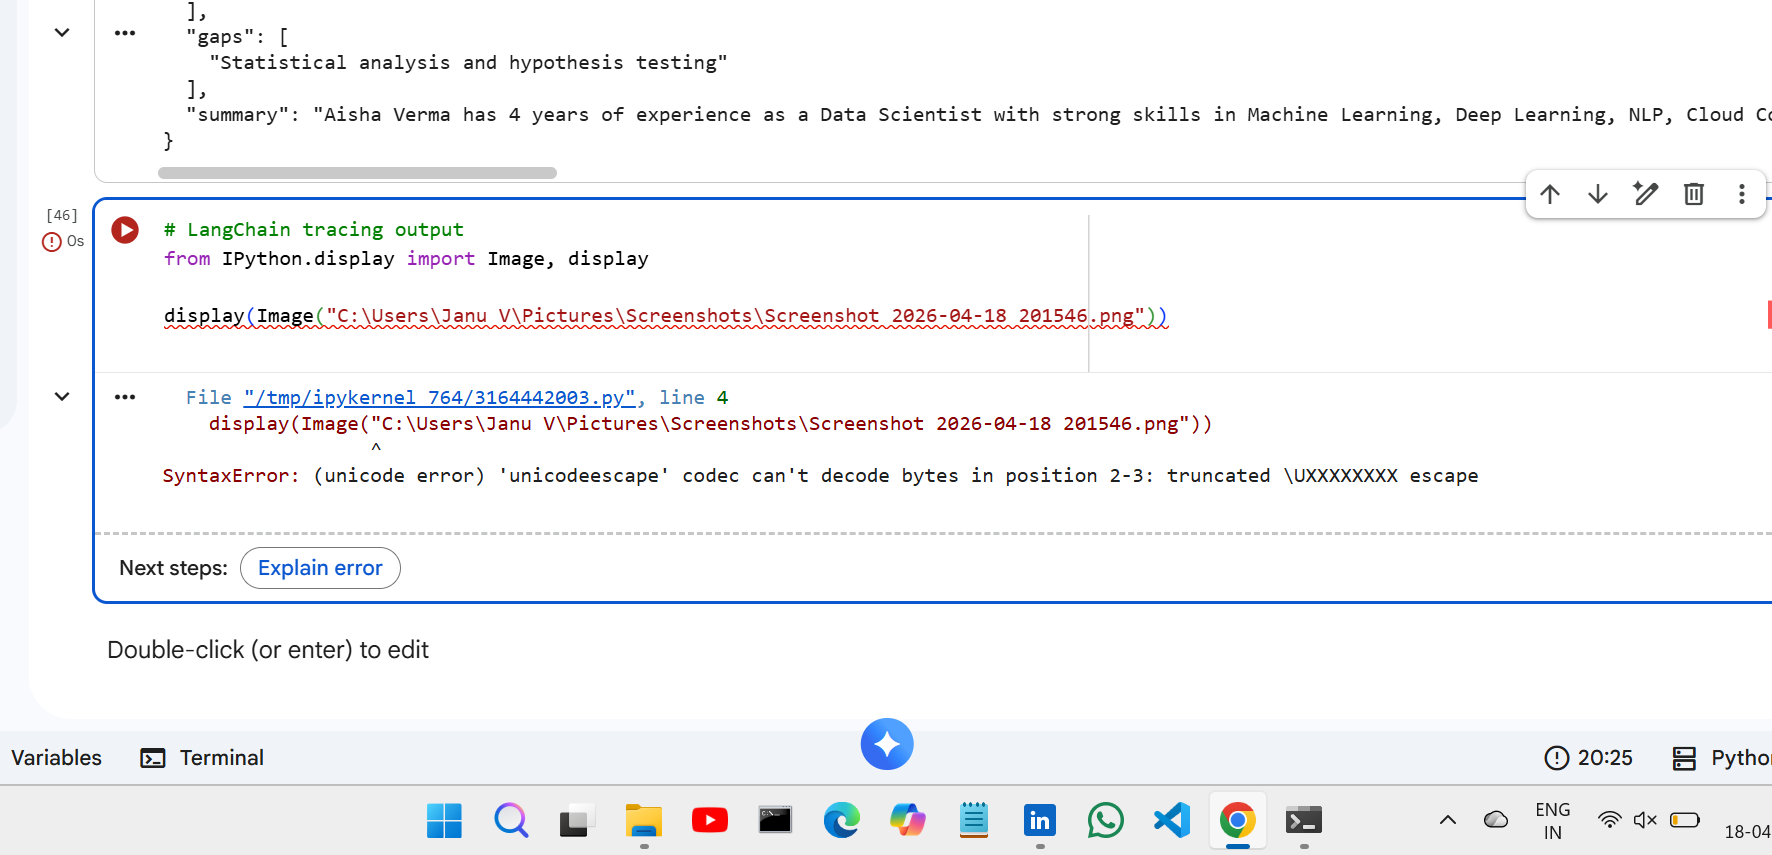

In [49]:
from IPython.display import Image, display
display(Image('/content/trace.png'))


## LangSmith

After all cells finish go to https://smith.langchain.com and open the **AI-Resume-Screening** project.

You will see:
- Strong Candidate - Aisha Verma
- Average Candidate - Rohan Mehta
- Weak Candidate - Priya Sharma
- Debug Run - Vikram Singh
- JSON Resume Screener

Each run shows all 4 pipeline stages as sub-steps. Take screenshots of the project overview and at least one run expanded with all stages visible.